# EuroSAT Land Use Classification with ResNet50

Classify Sentinel-2 satellite image patches into 10 land use classes using a ResNet50 model implemented from scratch.

## 1. Configuration

In [1]:
import os
import random
import numpy as np
import torch

# --- Paths ---
# Kaggle
DATA_DIR = "/kaggle/input/datasets/marwanmesbah19/eurosat-rgb-1/EuroSAT_RGB"
# Local:
# DATA_DIR = "../Dataset/EuroSAT_RGB"

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Hyperparameters ---
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 10
SEED = 42
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
PATIENCE = 8

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")

# --- Reproducibility ---
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True  # fixed 224x224 input → autotune is safe

seed_everything(SEED)

Device: cuda
Mixed precision: True


## 2. Imports

In [2]:
import copy
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, SubsetRandomSampler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

print("All imports successful.")

All imports successful.


## 3. Data Loading and Preprocessing

In [3]:
# Compute dataset-specific normalization statistics
# Use the same preprocessing as validation (resize + center crop) without normalization
stats_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
stats_dataset = datasets.ImageFolder(root=DATA_DIR, transform=stats_transform)
stats_loader = DataLoader(stats_dataset, batch_size=256, num_workers=2, pin_memory=True)

channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    batch_size = images.size(0)
    pixels = images.view(batch_size, images.size(1), -1)
    channel_sum += pixels.sum(2).sum(0)
    channel_sq_sum += (pixels ** 2).sum(2).sum(0)
    num_pixels += pixels.size(2) * batch_size

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)
del stats_dataset, stats_loader

print(f"Dataset mean: {mean.tolist()}")
print(f"Dataset std: {std.tolist()}")

# Training augmentations — designed for satellite imagery
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Validation/test transforms — deterministic
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

Dataset mean: [0.3454716205596924, 0.38130685687065125, 0.4088808000087738]
Dataset std: [0.20140625536441803, 0.135671466588974, 0.114350825548172]


In [4]:
# Load dataset and create train/val/test splits
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
dataset_size = len(full_dataset)

print(f"Classes ({len(class_names)}): {class_names}")
print(f"Total images: {dataset_size}")

# Shuffle and split indices
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_end = int(TRAIN_SPLIT * dataset_size)
val_end = train_end + int(VAL_SPLIT * dataset_size)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]  # remainder → test

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Create datasets with appropriate transforms (val_dataset reused for test)
train_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(train_idx),
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        sampler=SubsetRandomSampler(val_idx),
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         sampler=SubsetRandomSampler(test_idx),
                         num_workers=2, pin_memory=True)

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Train: 18900 | Val: 4050 | Test: 4050


## 4. Dataset Visualization

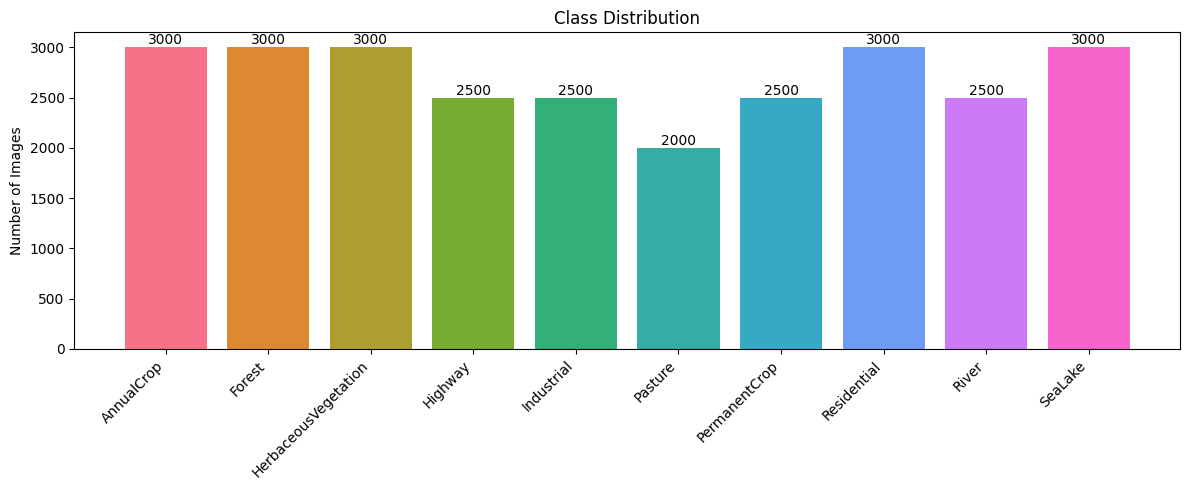

In [5]:
# Class distribution
class_counts = np.bincount(full_dataset.targets)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.show()

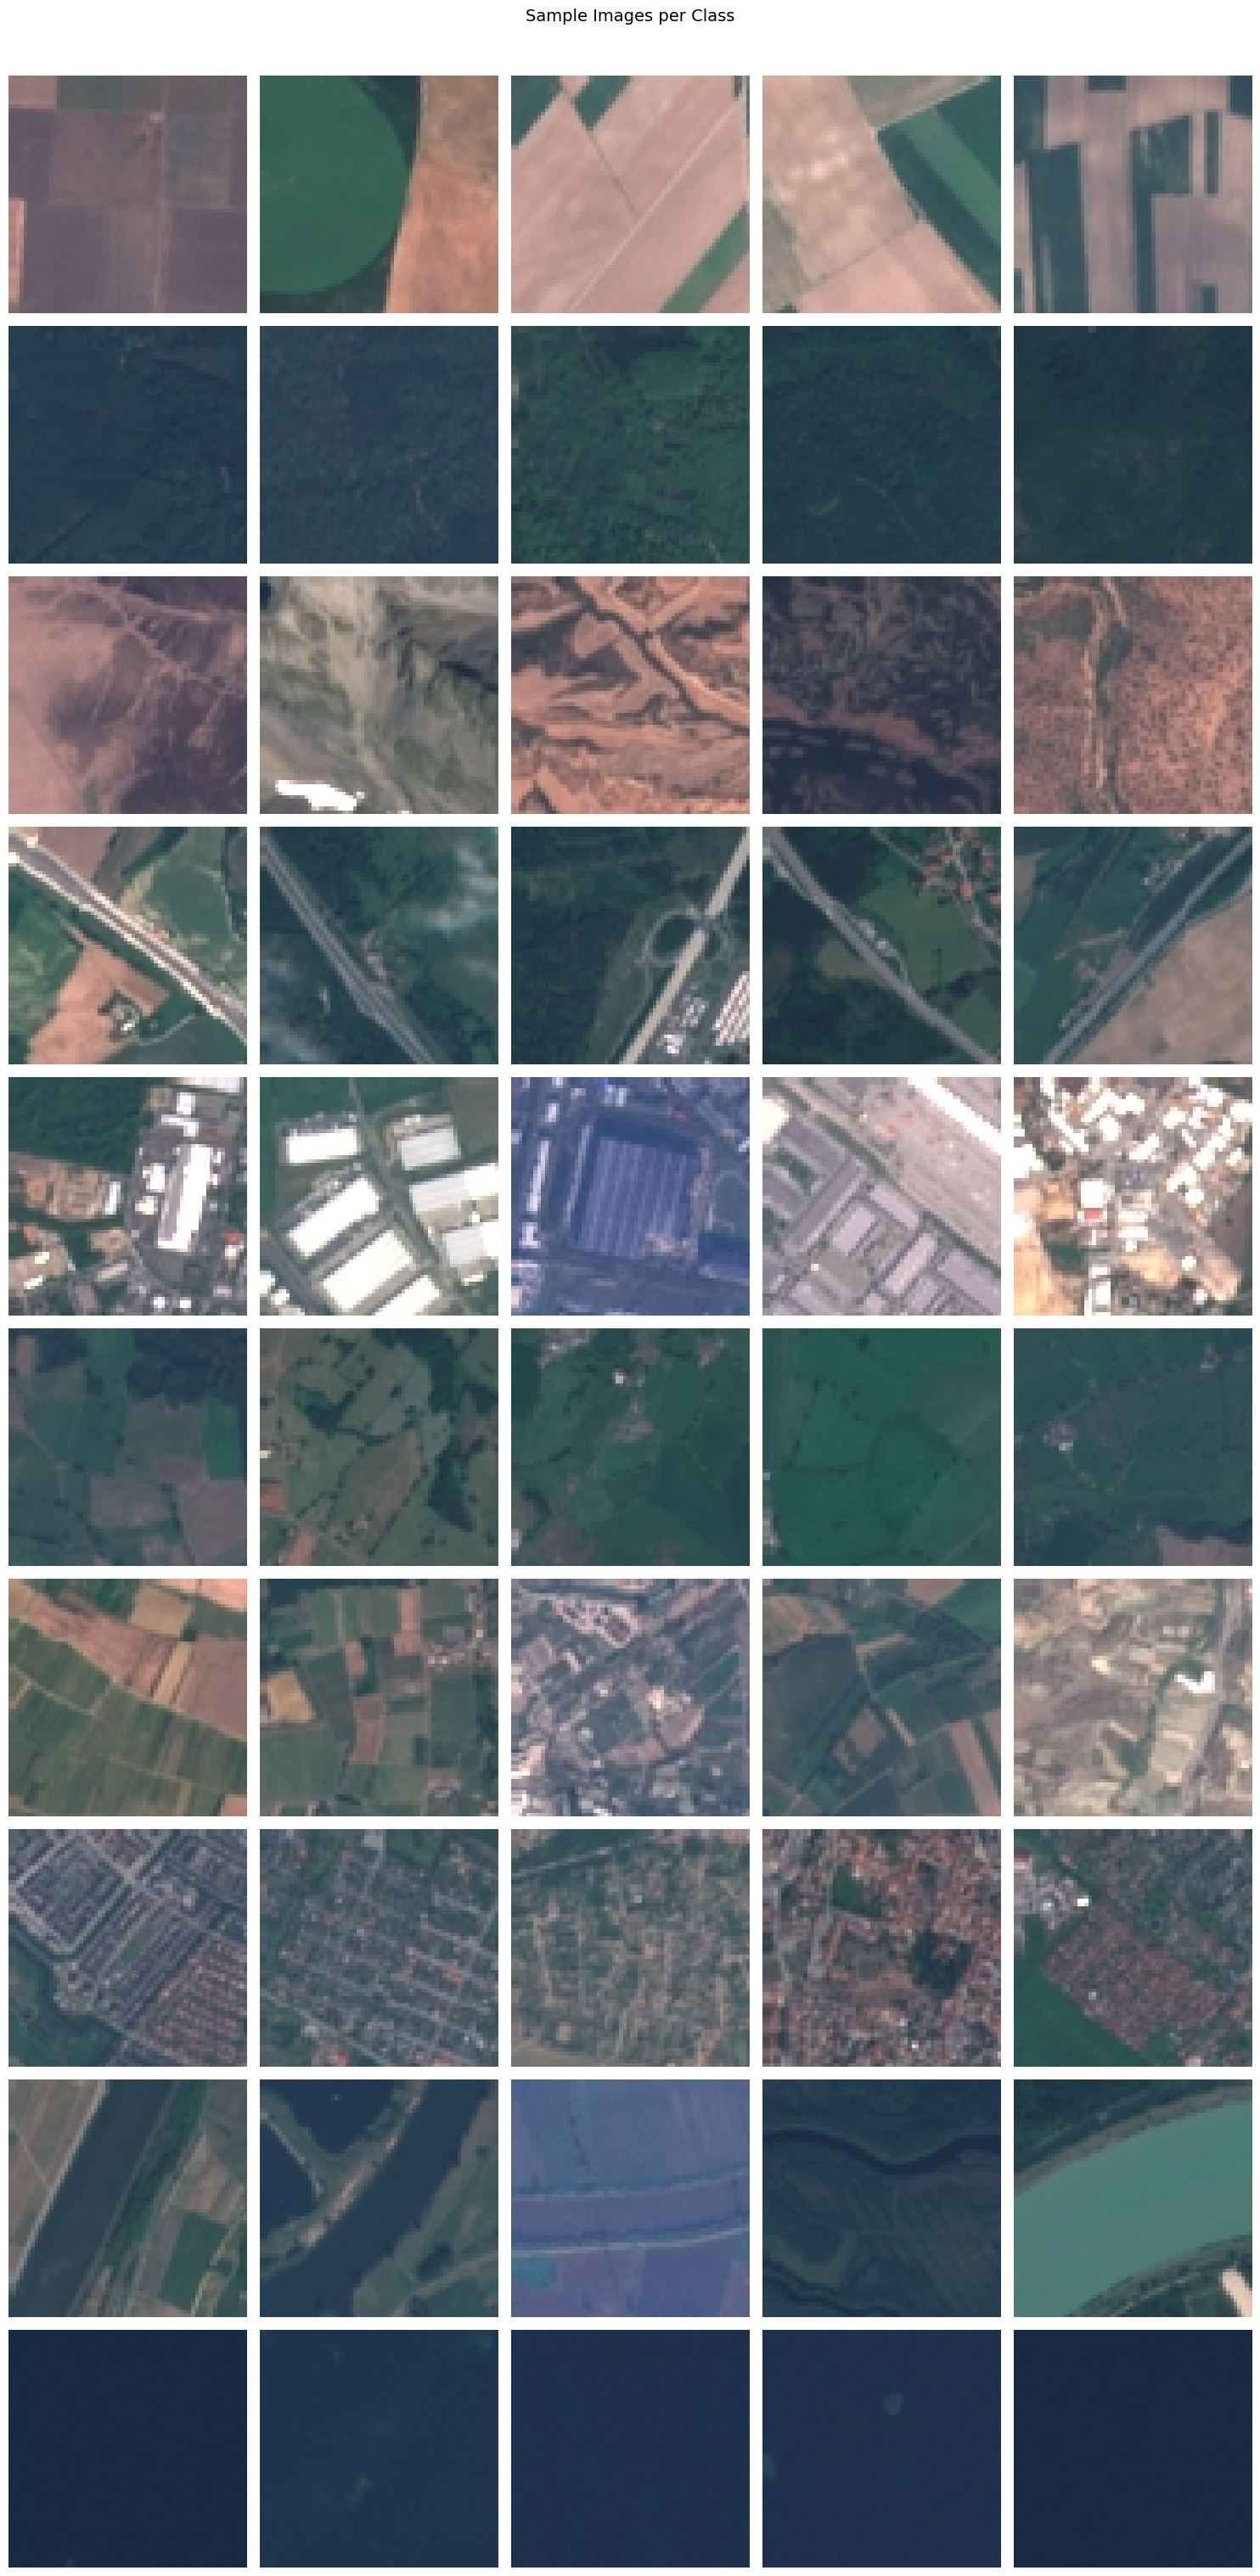

In [6]:
# Sample images from each class
# Inverse normalization: since Normalize does (x - mean) / std,
# passing (-mean/std, 1/std) reverses it back to pixel range
inv_normalize = transforms.Normalize(
    mean=[-m / s for m, s in zip(mean.tolist(), std.tolist())],
    std=[1.0 / s for s in std.tolist()]
)

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 30))
samples_per_class = {}
for img, label in full_dataset:
    name = class_names[label]
    if name not in samples_per_class:
        samples_per_class[name] = []
    if len(samples_per_class[name]) < 5:
        samples_per_class[name].append(img)
    if len(samples_per_class) == len(class_names) and all(len(v) == 5 for v in samples_per_class.values()):
        break

for i, cls in enumerate(class_names):
    for j in range(5):
        axes[i, j].imshow(samples_per_class[cls][j])
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10, rotation=0, labelpad=60)
plt.suptitle("Sample Images per Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_images.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Definition

In [7]:
# --- ResNet50 built from scratch ---

class Bottleneck(nn.Module):
    """ResNet50 bottleneck block: 1x1 → 3x3 → 1x1 with skip connection."""
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet50(nn.Module):
    """ResNet50 manually implemented from scratch."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Stem
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(64, 64, blocks=3, stride=1)
        self.layer2 = self._make_layer(256, 128, blocks=4, stride=2)
        self.layer3 = self._make_layer(512, 256, blocks=6, stride=2)
        self.layer4 = self._make_layer(1024, 512, blocks=3, stride=2)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * Bottleneck.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion),
            )

        layers = [Bottleneck(in_channels, out_channels, stride, downsample)]
        for _ in range(1, blocks):
            layers.append(Bottleneck(out_channels * Bottleneck.expansion, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# Create model
model = ResNet50(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,528,522
Trainable parameters: 23,528,522


## 6. Optimizer, Scheduler, and Loss

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"Mixed precision: {USE_AMP}")

Optimizer: AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=100)
Mixed precision: True


## 7. Training Loop

In [9]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = -1.0
best_model_wts = None
patience_counter = 0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- Training ---
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects / total

    # --- Validation ---
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_corrects / val_total
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    elapsed = time.time() - start_time

    # --- Record history ---
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] {elapsed:.0f}s | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}")

    # --- Checkpoint ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "class_names": class_names,
        }, os.path.join(OUTPUT_DIR, "best_resnet50_eurosat.pth"))
        patience_counter = 0
        print(f"  -> New best model saved (val_acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Starting training...



Epoch [1/100] 141s | Train Loss: 1.2210 Acc: 0.5748 | Val Loss: 1.1492 Acc: 0.6069 | LR: 0.000300
  -> New best model saved (val_acc: 0.6069)


Epoch [2/100] 124s | Train Loss: 0.7895 Acc: 0.7286 | Val Loss: 1.2606 Acc: 0.6427 | LR: 0.000300
  -> New best model saved (val_acc: 0.6427)


Epoch [3/100] 121s | Train Loss: 0.6441 Acc: 0.7788 | Val Loss: 0.5856 Acc: 0.8064 | LR: 0.000300
  -> New best model saved (val_acc: 0.8064)


Epoch [4/100] 121s | Train Loss: 0.5267 Acc: 0.8207 | Val Loss: 0.4451 Acc: 0.8568 | LR: 0.000299
  -> New best model saved (val_acc: 0.8568)


...

Epoch [62/100] 121s | Train Loss: 0.0508 Acc: 0.9823 | Val Loss: 0.0550 Acc: 0.9800 | LR: 0.000100


Epoch [63/100] 124s | Train Loss: 0.0438 Acc: 0.9847 | Val Loss: 0.0675 Acc: 0.9770 | LR: 0.000095


Epoch [64/100] 122s | Train Loss: 0.0411 Acc: 0.9860 | Val Loss: 0.0703 Acc: 0.9743 | LR: 0.000091


Epoch [65/100] 122s | Train Loss: 0.0381 Acc: 0.9863 | Val Loss: 0.0595 Acc: 0.9795 | LR: 0.000087


Epoch [66/100] 122s | Train Loss: 0.0388 Acc: 0.9856 | Val Loss: 0.0631 Acc: 0.9788 | LR: 0.000083

Early stopping at epoch 66

Best validation accuracy: 0.9800


## 8. Training Curves

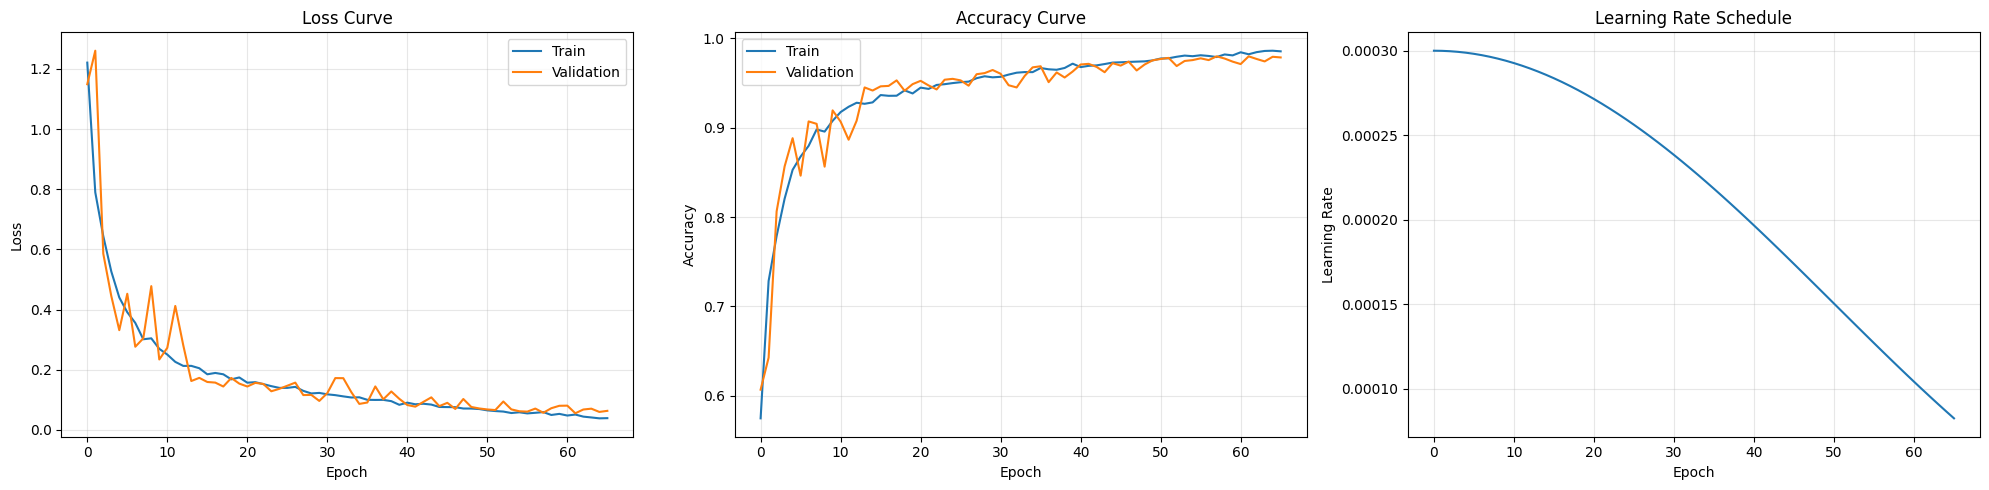

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history["lr"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 9. Test Evaluation

In [ ]:
# Load best model
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs)

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Macro F1:       {macro_f1:.4f}")
print(f"Weighted F1:    {weighted_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Testing: 100%|██████████| 64/64 [00:08<00:00,  7.15it/s]

Test Accuracy:  0.9758
Macro F1:       0.9748
Weighted F1:    0.9758

                      precision    recall  f1-score   support

          AnnualCrop     0.9449    0.9772    0.9608       439
              Forest     0.9955    0.9933    0.9944       447
HerbaceousVegetation     0.9591    0.9679    0.9635       436
             Highway     0.9734    0.9786    0.9760       374
          Industrial     0.9816    0.9816    0.9816       380
             Pasture     0.9460    0.9813    0.9634       268
       PermanentCrop     0.9776    0.9136    0.9445       382
         Residential     0.9907    0.9953    0.9930       430
               River     0.9785    0.9738    0.9761       420
             SeaLake     1.0000    0.9895    0.9947       474

            accuracy                         0.9758      4050
           macro avg     0.9747    0.9752    0.9748      4050
        weighted avg     0.9760    0.9758    0.9758      4050



## 10. Confusion Matrix

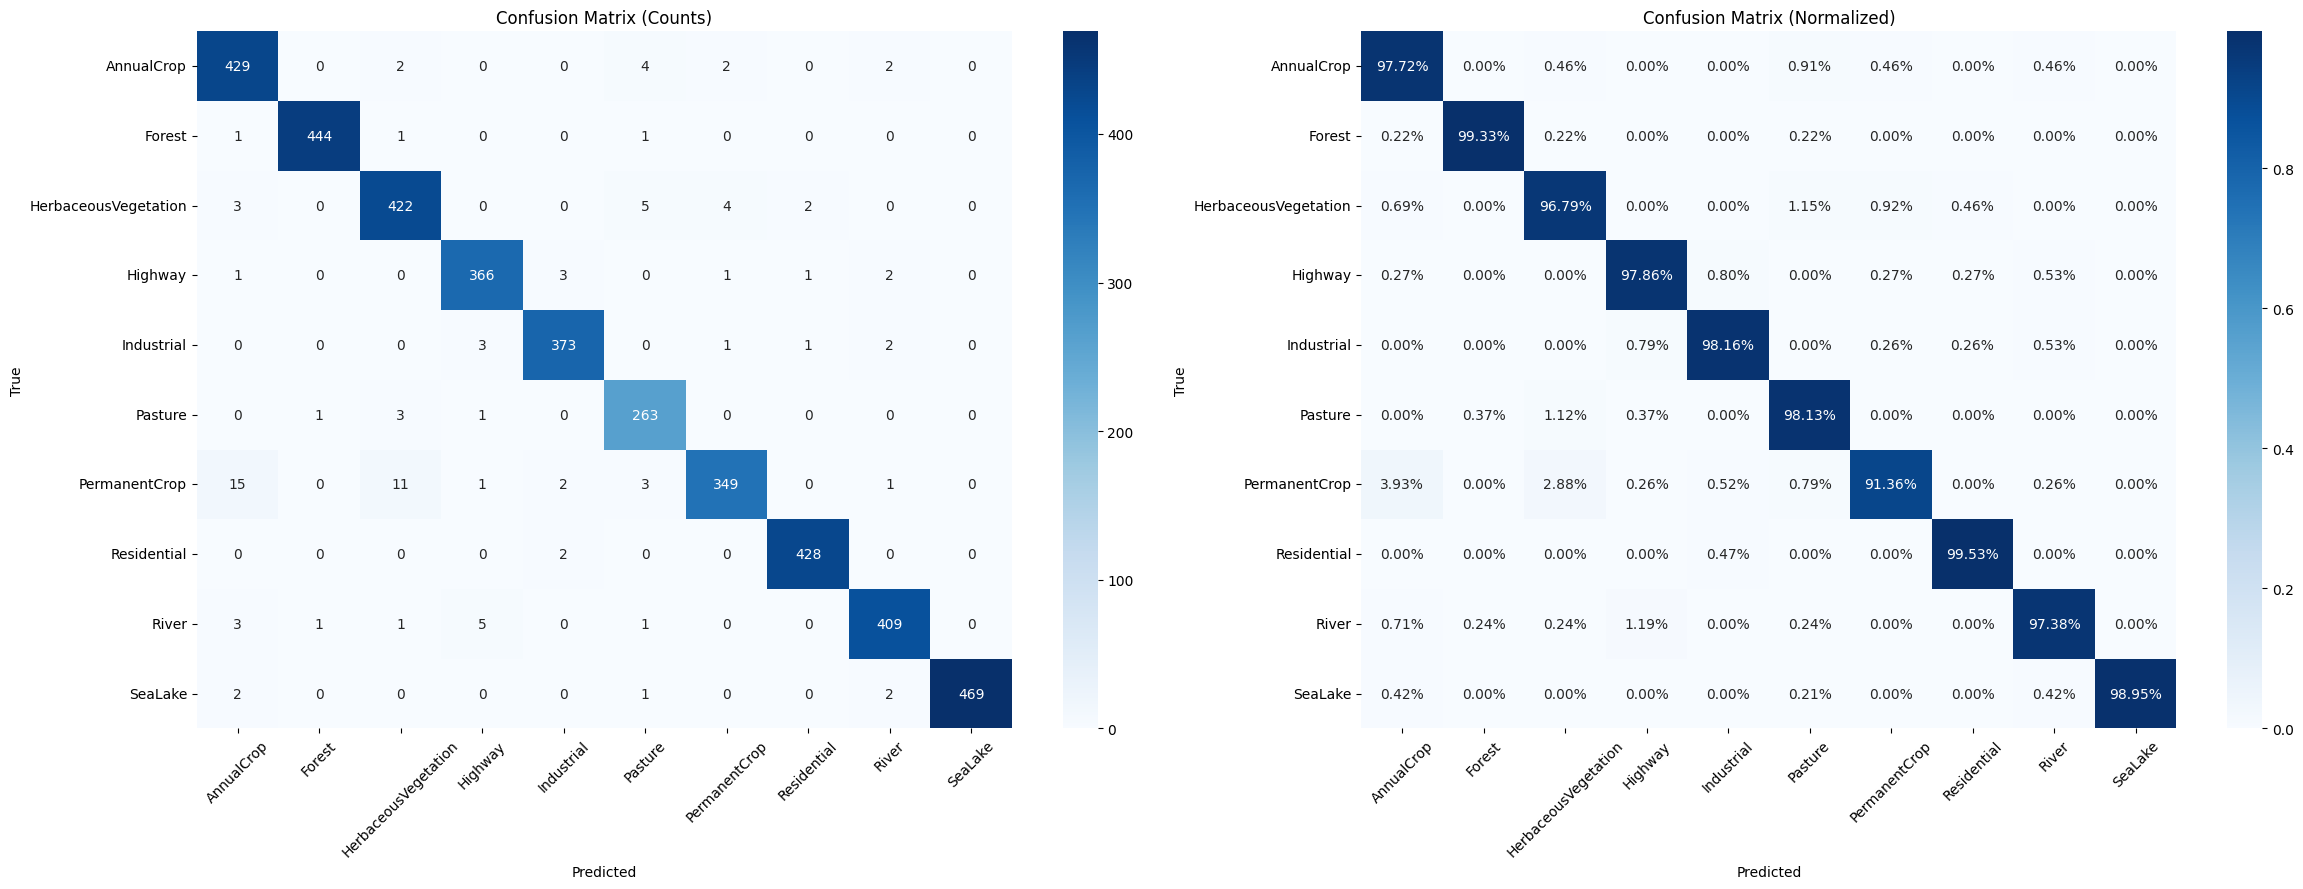

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 11. Per-Class Accuracy

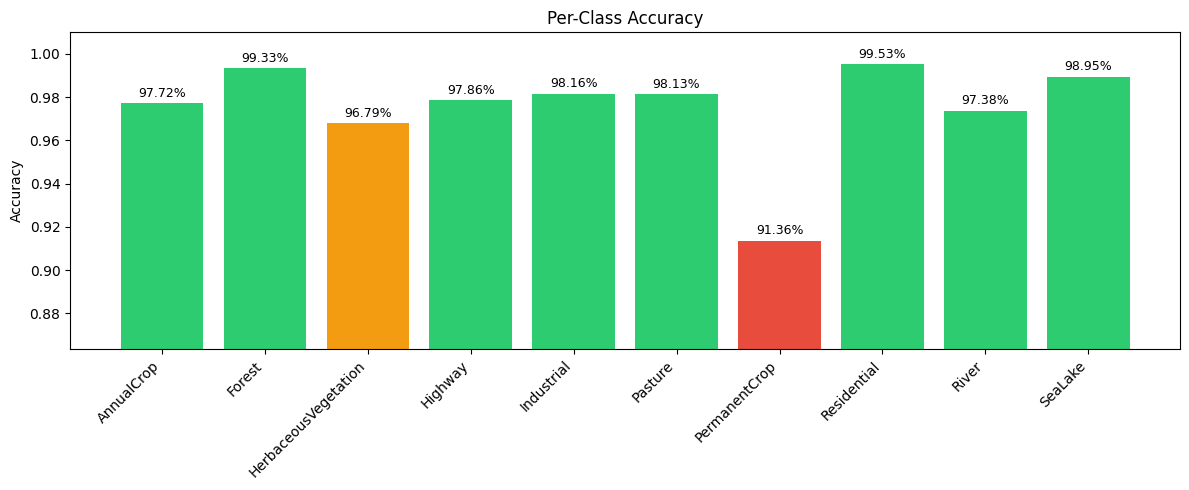

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if acc >= 0.97 else "#e74c3c" if acc < 0.93 else "#f39c12" for acc in per_class_acc]
bars = ax.bar(class_names, per_class_acc, color=colors)
ax.set_ylim(min(per_class_acc) - 0.05, 1.01)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
plt.xticks(rotation=45, ha="right")

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{acc:.2%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_accuracy.png"), dpi=150)
plt.show()

## 12. Sample Predictions

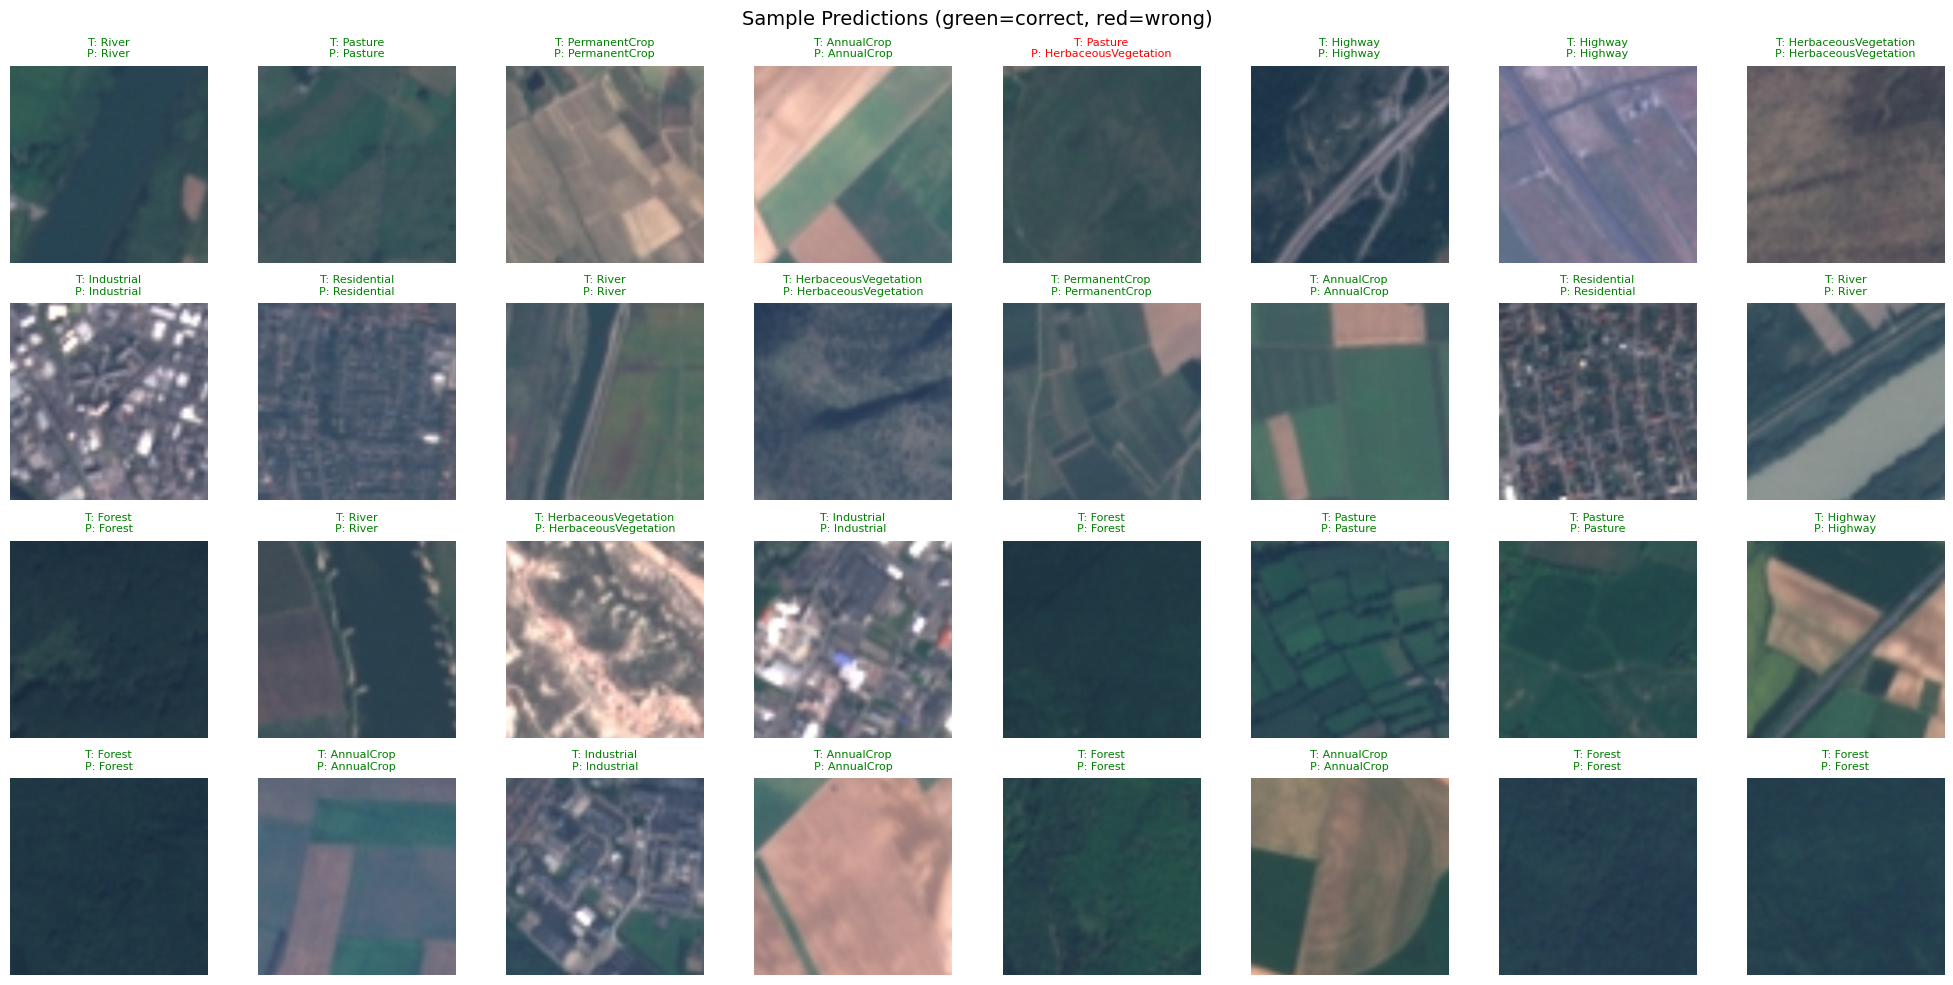

In [ ]:
# Show test images with predictions
model.eval()
images_shown, num_rows, num_cols = 0, 4, 8

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_gpu = inputs.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs_gpu)
        _, preds = torch.max(outputs, 1)

        for i in range(inputs.size(0)):
            if images_shown >= num_rows * num_cols:
                break

            row, col = images_shown // num_cols, images_shown % num_cols
            img = inv_normalize(inputs[i]).permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            true_name = class_names[labels[i]]
            pred_name = class_names[preds[i].item()]
            correct = true_name == pred_name

            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"T: {true_name}\nP: {pred_name}",
                fontsize=8, color="green" if correct else "red"
            )
            axes[row, col].axis("off")
            images_shown += 1

        if images_shown >= num_rows * num_cols:
            break

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
plt.show()

## 13. Save Final Artifacts

In [ ]:
# Save best model weights
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "resnet50_eurosat_best.pth"))

# Save classification report as CSV
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index_label="epoch")

print("Saved:")
print(f"  - resnet50_eurosat_best.pth")
print(f"  - classification_report.csv")
print(f"  - training_history.csv")
print(f"  - best_resnet50_eurosat.pth (best checkpoint with optimizer state)")

Saved:
  - resnet50_eurosat_best.pth
  - classification_report.csv
  - training_history.csv
  - best_resnet50_eurosat.pth (best checkpoint with optimizer state)
